# Introduction to rhythm counting

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In music the taal or counting system is denoted by the time signature. The time signature has two parts, the numerator and denominator.

The numerator is the number of beats in a bar, and the denominator denotes the size of the beat as a fraction.

The most common time signature is 4/4. The numerator shows there are 4 beats in a measure, and the denominator represents each beat is a quarter.

If the time signature is 7/8, then this means each beat is 1/8th and there are 7 of these beats in a measure.

In MIDI the unit of time is a 'tick' and the standard unit is called a TICKS_PER_QUARTER. 
FluidMidi sets it at 480. To convert this time scale to real time units we need to set the tempo.

Tempo is measured in beats per minute. Eg:
If tempo is 120 bpm. Then each beat is `(120 / 60) ** -1` = 0.5 s

If the denominator of the time signature is 4, then the unit beat is a quarter. Since a quarter beat is 480 ticks, 480 ticks = 0.5 s.

Rhythm is counted in a hierarchy of scales. If the numerator of the time signature is 4, then 4 beats make a bar (a.k.a measure). 4 measures make a phrase. Usually 4 phrases make a verse or section. Now each beat is divided into subdivisions of eights or 1/16ths, or triplets, etc. So in the quantized time grid we can locate an event as (phrase, bar, beat, subdivision, residue). The residue represents the delta difference if an event is not quantized on the grid.

In [9]:
# Counting system
quarter = 480  # ticks
tsig_nume, tsig_deno = 4, 4

beat_dur = quarter * 4 / tsig_deno
subdivs = 2  # 2 for 8ths, 4 for 16th, etc
beats_in_bar = tsig_nume
bars_in_phrase = 4

In [10]:
bar_dur = beats_in_bar * beat_dur
phrase_dur = bar_dur * bars_in_phrase
subdiv_dur = beat_dur // subdivs

In [11]:
phrase_dur, bar_dur, beat_dur, subdiv_dur

(7680.0, 1920.0, 480.0, 240.0)

In [12]:
# times = drums['time']
times = np.arange(0, 128) * subdiv_dur
phrase = times // phrase_dur
res = times % phrase_dur
bar = res // bar_dur
res = res % bar_dur
beat = res // beat_dur
res = res % beat_dur
subdiv = res // subdiv_dur
res = res % subdiv_dur
data = np.vstack((phrase, bar, beat, subdiv, res))

In [15]:
import matplotlib.ticker as ticker

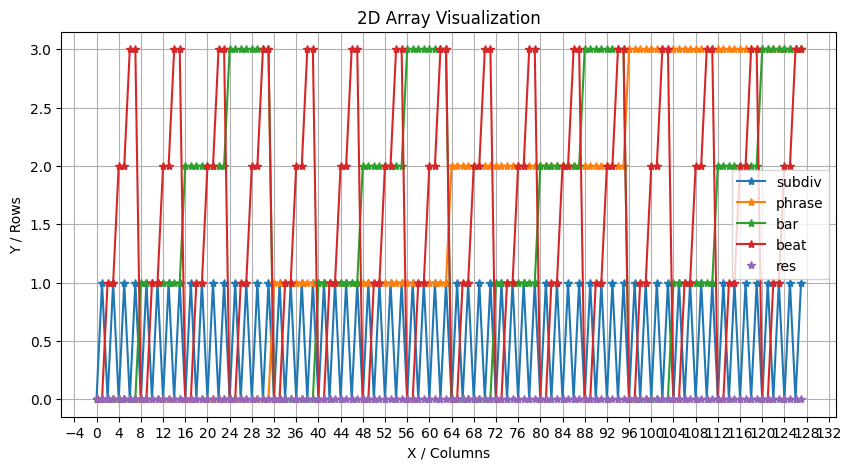

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title("2D Array Visualization")
ax.set_xlabel("X / Columns")
ax.set_ylabel("Y / Rows")

ax.plot(subdiv, '*-')
ax.plot(phrase, '*-')
ax.plot(bar, '*-')
ax.plot(beat, '*-')
ax.plot(res / 20, '*')
plt.legend(['subdiv', 'phrase', 'bar', 'beat', 'res'])
ax.xaxis.set_major_locator(ticker.MultipleLocator(beats_in_bar))
# ax.plot(res)
plt.grid()
plt.show()